<a href="https://colab.research.google.com/github/audomsak-pypy/Project1-Text_Analytics69/blob/sukanya/Part1_673020264_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Part 1: Social Listening Warm-up (10 คะแนน)
**วิชา:** SC 663 402 Data Warehouse and Big Data Analytics  
**ผู้จัดทำ:** สุกัญญา อุดมกัน 673020264-7  
**แหล่งข้อมูล:** [alpindale/two-million-bluesky-posts](https://huggingface.co/datasets/alpindale/two-million-bluesky-posts)  
**ขอบเขต:** ข้อมูลโพสต์ Bluesky สาธารณะจากไฟล์ JSONL 3 ไฟล์ที่เลือกไว้ล่วงหน้า (ชุดข้อมูลย้อนหลัง พ.ย. 2024)

> **หมายเหตุเรื่องโจทย์:** Part 1 ใช้ Bluesky ตามโจทย์อาจารย์ ส่วน `Digital_Music` ที่เลือกไว้เป็นหมวดรีวิว Amazon สำหรับ **Part 2** ไม่ใช่ชุดข้อมูล Part 1. ใน Part 1 นี้มีตัวอย่างสำรวจเรื่องดนตรีเป็นส่วนเสริมเท่านั้น

**คำถาม 4 ข้อ:** (1) โพสต์เมื่อไร (2) ภาษาอะไร (3) พูดถึงอะไร และ (4) บอกอะไรได้/ไม่ได้พร้อมกราฟอย่างน้อย 1 รูป. โค้ดสร้างตาราง หลักฐาน และคำตอบจากผลจริงหลังรัน ไม่ใส่ตัวเลขสมมติไว้ล่วงหน้า.

## 0. แผนการวิเคราะห์และเหตุผลเลือกเทคนิค
- **Data collection:** ใช้ `hf_hub_download()` จากแหล่งที่อาจารย์กำหนด โดยเลือกไฟล์ JSONL ต้นฉบับ 3 ไฟล์ที่เรียงต่อเนื่องเพื่อไม่ให้คัดเฉพาะช่วงที่สนใจภายหลัง
- **Data cleaning:** อ่านทีละบรรทัดด้วย generator, ตรวจ `text`, `created_at`, `uri` และตัดข้อมูลซ้ำ; แสดงจำนวนก่อน/หลัง clean
- **EDA:** `pandas.groupby()` นับเวลาเป็น UTC; ไม่แปล UTC เป็นเวลาท้องถิ่นของผู้โพสต์
- **Languages:** ใช้ `predicted_language` เมื่อไฟล์มีและครอบคลุมเพียงพอ; ถ้าไม่มี ใช้ `langdetect` กับ *random sample* แบบ seed คงที่ และแสดงชัดว่าเป็นค่าประมาณ
- **Topics:** Regex สำหรับ hashtag + Bigram frequency สำหรับสำรวจคำ/วลี และตัวอย่างโพสต์จริง โดยไม่สรุปจาก Word Cloud อย่างเดียว
- **Visualization:** สร้างไฟล์กราฟ 1 รูป (เวลาและภาษา) และตาราง hashtag; ตีความเฉพาะโพสต์ในไฟล์ที่เลือก

**แหล่งความรู้จากไฟล์เรียน:** `Class1Intro_66.pdf` (Data Analytics), `SC612104_2_การเตรียมข้อมูล.pdf` (data cleaning), `Class3DataVisualization_66.pdf` (ออกแบบกราฟ), `SC663402_Pandas_Review.ipynb`, `Regular_Expression.ipynb`, `BeautifulSoup.ipynb`, `Scrape_Twitter.ipynb`, `NLP.ipynb`, `HuggingFace.ipynb`, `Sentiment Analysis.pdf`. เอกสารตัวอย่าง `NASA.csv`, `ElonMusk.docx`, `thailand_tweets.txt` ใช้ศึกษารูปแบบ social-media fields เท่านั้น **ไม่ได้ปะปนเข้ากับ dataset ของ Part 1**.

In [ ]:
# 1. Setup — Colab: รันเซลล์นี้ครั้งแรกเพื่อเตรียมแพ็กเกจ
%pip -q install pandas numpy matplotlib scikit-learn huggingface_hub langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# 2. กำหนดค่าคงที่และไฟล์ที่ใช้
import json, re, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RANDOM_SEED = 42
SAMPLE_N = 5_000               # เพดานสุ่มตรวจภาษา หากไม่มี predicted_language
TOPIC_SAMPLE_N = 20_000        # เพดานสุ่มสำหรับ bigram (ใช้เฉพาะสำรวจ)
REPO_ID = 'alpindale/two-million-bluesky-posts'
# ตรึง revision ไฟล์ข้อมูลไว้เพื่อทำซ้ำได้ แม้ README จะเปลี่ยนในอนาคต
REVISION = '4fda3b7f94f5f26871eec747d8217bab753c4d84'
FILENAMES = [
    'posts_20241127_075630.jsonl',
    'posts_20241127_082640.jsonl',
    'posts_20241127_085625.jsonl',
]
DATA_DIR = Path('data')
RESULTS_DIR = Path('part1_results')
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Files selected:', *FILENAMES, sep='\n - ')
print('RANDOM_SEED:', RANDOM_SEED, '| SAMPLE_N:', SAMPLE_N)

Files selected:
 - posts_20241127_075630.jsonl
 - posts_20241127_082640.jsonl
 - posts_20241127_085625.jsonl
RANDOM_SEED: 42 | SAMPLE_N: 5000


In [ ]:
# 3. ดาวน์โหลดหรือใช้ไฟล์ที่มีอยู่แล้ว
from huggingface_hub import hf_hub_download

paths = []
for name in FILENAMES:
    local = DATA_DIR / name
    if local.is_file() and local.stat().st_size > 0:
        path = local
        print('CACHED:', path, '|', round(local.stat().st_size/1e6, 2), 'MB')
    else:
        path = Path(hf_hub_download(
            repo_id=REPO_ID, repo_type='dataset', filename=name,
            revision=REVISION, local_dir=str(DATA_DIR)
        ))
        print('DOWNLOADED:', path, '|', round(path.stat().st_size/1e6, 2), 'MB')
    paths.append(path)

assert 1 <= len(paths) <= 3
assert all(p.is_file() and p.stat().st_size > 0 for p in paths)

posts_20241127_075630.jsonl: reconstructing file:   0%|          |  0.00B / 39.9MB            

posts_20241127_075630.jsonl: downloading bytes:           |  0.00B            

DOWNLOADED: /content/data/posts_20241127_075630.jsonl | 39.93 MB


posts_20241127_082640.jsonl: reconstructing file:   0%|          |  0.00B / 40.1MB            

posts_20241127_082640.jsonl: downloading bytes:           |  0.00B            

DOWNLOADED: /content/data/posts_20241127_082640.jsonl | 40.14 MB


posts_20241127_085625.jsonl: reconstructing file:   0%|          |  0.00B / 40.5MB            

posts_20241127_085625.jsonl: downloading bytes:           |  0.00B            

DOWNLOADED: /content/data/posts_20241127_085625.jsonl | 40.45 MB


In [ ]:
# 4. อ่าน JSONL ทีละบรรทัด เก็บเฉพาะฟิลด์ที่ใช้วิเคราะห์ และบันทึกตัวนับข้อมูลเสีย
FIELDS = ('uri', 'text', 'created_at', 'predicted_language', 'language_confidence')

def iter_jsonl(path):
    with open(path, encoding='utf-8') as f:
        for line_number, line in enumerate(f, 1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
                if not isinstance(record, dict):
                    raise ValueError('Expected JSON object')
                yield line_number, record, None
            except (json.JSONDecodeError, ValueError) as exc:
                yield line_number, None, repr(exc)

rows = []
invalid_json = 0
raw_records = 0
for path in paths:
    for line_no, item, error in iter_jsonl(path):
        if error:
            invalid_json += 1
            print(f'JSON ERROR: {path.name}:{line_no} {error[:100]}')
            continue
        raw_records += 1
        row = {col: item.get(col) for col in FIELDS}
        row['_source_file'] = path.name
        rows.append(row)

raw_df = pd.DataFrame(rows)
if raw_df.empty:
    raise ValueError('ไม่มีข้อมูลจากไฟล์ที่ดาวน์โหลด โปรดตรวจสอบไฟล์')

print('Records read =', raw_records, '| Invalid JSON =', invalid_json)
print('Columns =', raw_df.columns.tolist())
display(raw_df[['created_at','text','predicted_language','_source_file']].head(3))

Records read = 300000 | Invalid JSON = 0
Columns = ['uri', 'text', 'created_at', 'predicted_language', 'language_confidence', '_source_file']


,created_at,text,predicted_language,_source_file
0,2024-11-27T07:56:28.535Z,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,None,posts_20241127_075630.jsonl
1,2024-11-27T07:56:28.717Z,Lovely stuff.,None,posts_20241127_075630.jsonl
2,2024-11-27T07:56:21.343Z,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,None,posts_20241127_075630.jsonl


In [ ]:
# 5. Quality checks: ไม่สร้างวันที่แทนเมื่อเวลาเสีย และไม่นับโพสต์ซ้ำสองรอบ
missing_text = raw_df['text'].isna() | raw_df['text'].astype(str).str.strip().eq('')
raw_dt = pd.to_datetime(raw_df['created_at'], utc=True, errors='coerce', format='mixed')
missing_dt = raw_dt.isna()
invalid_rows = missing_text | missing_dt
valid_df = raw_df.loc[~invalid_rows].copy()
valid_df['created_at'] = raw_dt.loc[~invalid_rows]
valid_df['text'] = valid_df['text'].astype(str).str.strip()
valid_df['uri'] = valid_df['uri'].fillna('').astype(str)

# deduplicate เฉพาะ URI ที่ไม่ว่าง; ถ้า URI หายไปใช้ (เวลา, ข้อความ) เป็น fallback
key = np.where(
    valid_df['uri'].str.len().gt(0),
    valid_df['uri'],
    valid_df['created_at'].astype(str) + '|' + valid_df['text']
)
valid_df['_dedup_key'] = key
dup_count = int(valid_df['_dedup_key'].duplicated().sum())
df = valid_df.drop_duplicates('_dedup_key').copy().reset_index(drop=True)
df['hour_utc'] = df['created_at'].dt.hour

quality = pd.DataFrame({'รายการ': [
    'อ่านได้จาก JSONL', 'JSON เสีย', 'ข้อความว่าง', 'เวลาไม่ถูกต้อง',
    'แถวที่ข้อมูลไม่ครบ (นับไม่ซ้ำกรณีขาดหลายช่อง)',
    'โพสต์ซ้ำหลังตรวจข้อมูล', 'โพสต์หลังทำความสะอาด'
], 'จำนวน': [raw_records, invalid_json, int(missing_text.sum()), int(missing_dt.sum()),
           int(invalid_rows.sum()), dup_count, len(df)]})
display(quality)
assert len(df) > 0, 'ไม่มีแถวที่มีข้อมูลครบ'
assert df['_dedup_key'].is_unique

,รายการ,จำนวน
0,อ่านได้จาก JSONL,300000
1,JSON เสีย,0
2,ข้อความว่าง,9068
3,เวลาไม่ถูกต้อง,0
4,แถวที่ข้อมูลไม่ครบ (นับไม่ซ้ำกรณีขาดหลายช่อง),9068
5,โพสต์ซ้ำหลังตรวจข้อมูล,2
6,โพสต์หลังทำความสะอาด,290930


## 1. คนโพสต์เมื่อไร?
นับเฉพาะโพสต์ที่ผ่านการตรวจคุณภาพแล้วด้วย `groupby('hour_utc')`. ผลลัพธ์สะท้อนเฉพาะช่วงเวลาในไฟล์ที่เลือก ไม่ใช่รูปแบบกิจกรรมตลอด 24 ชั่วโมงหรือเขตเวลาของผู้เขียน.

In [ ]:
# 6. จำนวนและช่วงเวลาที่ครอบคลุม
hourly = (df.groupby('hour_utc').size().rename('n_posts')
          .reset_index().sort_values('hour_utc'))
start_utc = df['created_at'].min()
end_utc = df['created_at'].max()
max_posts = hourly['n_posts'].max()
peak_hours = hourly.loc[hourly['n_posts'].eq(max_posts), 'hour_utc'].tolist()

print('จำนวนโพสต์หลัง clean:', f'{len(df):,}', 'โพสต์')
print('ช่วงข้อมูล (UTC):', start_utc.isoformat(), 'ถึง', end_utc.isoformat())
print('ชั่วโมงที่โพสต์มากที่สุดในข้อมูลที่เลือก:', ', '.join(f'{h:02d}:00–{h:02d}:59 UTC' for h in peak_hours),
      '|',f'{int(max_posts):,}','โพสต์')
display(hourly)

จำนวนโพสต์หลัง clean: 290,930 โพสต์
ช่วงข้อมูล (UTC): 2007-10-19T21:50:33+00:00 ถึง 2024-11-30T10:50:04.343000+00:00
ชั่วโมงที่โพสต์มากที่สุดในข้อมูลที่เลือก: 08:00–08:59 UTC | 176,851 โพสต์


,hour_utc,n_posts
0,0,924
1,1,861
2,2,784
3,3,732
4,4,668
5,5,803
6,6,779
7,7,10978
8,8,176851
9,9,77897


## 2. ใช้ภาษาอะไร?
ไฟล์ JSONL ต้นฉบับอาจไม่มี `predicted_language` แม้ README ระบุว่ามีการคาดเดาภาษาในอีก configuration หนึ่ง. โค้ดนี้ไม่สมมติว่าฟิลด์ดังกล่าวมีเสมอ: ถ้ามีอย่างน้อย 90% ของโพสต์จะใช้ฟิลด์นั้นโดยตรง; มิฉะนั้นสุ่มข้อความมาตรวจด้วย `langdetect` ด้วย seed คงที่ และรายงานฐานจำนวนเป็น `n` ของ sample. ผลตรวจภาษาเป็นการคาดเดาจากเครื่องมือ ไม่ใช่ภาษาที่ผู้เขียนแจ้งยืนยันเอง.

In [ ]:
# 7. สัดส่วนภาษา (ทั้งชุดเมื่อมี labels ครบ มิฉะนั้นใช้ random sample)
ISO3_TO_ISO2 = {
    'eng':'en','tha':'th','spa':'es','deu':'de','fra':'fr','por':'pt',
    'jpn':'ja','kor':'ko','zho':'zh','ind':'id','ita':'it','rus':'ru',
    'nld':'nl','ara':'ar','hin':'hi','vie':'vi','tur':'tr','pol':'pl'
}
def normalize_language(x):
    if not isinstance(x, str) or not x.strip():
        return 'und'
    tag = x.strip().split('_',1)[0].lower()
    return ISO3_TO_ISO2.get(tag, tag)

labeled = df['predicted_language'].fillna('').astype(str).str.strip().ne('')
label_coverage = float(labeled.mean())
if label_coverage >= 0.90:
    lang_obs = df.loc[labeled, ['text','predicted_language']].copy()
    lang_obs['language'] = lang_obs['predicted_language'].map(normalize_language)
    lang_method = 'predicted_language field (dataset predictions)'
else:
    from langdetect import detect, DetectorFactory
    from langdetect.lang_detect_exception import LangDetectException
    DetectorFactory.seed = RANDOM_SEED
    lang_obs = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_SEED)[['text']].copy()
    def safe_detect(text):
        # สั้นเกินไปมีโอกาสสูงที่จะเดาภาษาผิด แยกเป็น und
        if len(text.strip()) < 20 or not any(char.isalpha() for char in text):
            return 'und'
        try:
            return detect(text)
        except LangDetectException:
            return 'und'
    lang_obs['language'] = lang_obs['text'].map(safe_detect)
    lang_method = f'langdetect on fixed random sample (n={len(lang_obs):,}, seed={RANDOM_SEED})'

language_table = (lang_obs['language'].fillna('und').value_counts(dropna=False)
                  .rename_axis('language').reset_index(name='n_posts'))
language_table['percent'] = 100 * language_table['n_posts'] / len(lang_obs)
language_table['percent'] = language_table['percent'].round(2)
print('ภาษาได้จาก:', lang_method)
print('สัดส่วน label ในไฟล์:', f'{label_coverage:.1%}', '| n analyzed:', f'{len(lang_obs):,}')
display(language_table.head(15))
main_language = language_table.iloc[0]['language']
main_language_percent = float(language_table.iloc[0]['percent'])

ภาษาได้จาก: langdetect on fixed random sample (n=5,000, seed=42)
สัดส่วน label ในไฟล์: 0.0% | n analyzed: 5,000


,language,n_posts,percent
0,en,2259,45.18
1,und,902,18.04
2,ja,558,11.16
3,es,252,5.04
4,de,186,3.72
5,fr,160,3.20
6,ko,109,2.18
7,pt,70,1.40
8,nl,58,1.16
9,pl,45,0.90


## 3. คนพูดถึงอะไร?
Regex ดึง `#hashtag` นับแบบ *จำนวนโพสต์ที่มี hashtag* (ไม่นับ tag เดิมซ้ำในโพสต์เดียว). นำเสนอ 3 ตัวอย่างข้อความจริงของ hashtag อันดับแรก. ใช้ bigram บน subset ขนาดกำหนดเพื่อช่วยมองวลีที่น่าสนใจ; วลีที่พบบ่อยเป็นเพียงข้อสังเกต ไม่ใช่ความสนใจของประชากรทั้งหมด.

In [ ]:
# 8. Hashtag frequency และข้อความตัวอย่างจริง
# Unicode regex รองรับคำและ hashtag ภาษาไทยด้วย
HASHTAG_RE = re.compile(r'(?<!\w)#([^\W_][\w]*)', flags=re.UNICODE)

def get_tags(text):
    return {m.group(1).casefold() for m in HASHTAG_RE.finditer(text)}

df['hashtags'] = df['text'].map(get_tags)
tag_counter = Counter(tag for tags in df['hashtags'] for tag in tags)
hashtag_table = pd.DataFrame(tag_counter.most_common(15), columns=['hashtag','n_posts'])
if not hashtag_table.empty:
    hashtag_table['percent_of_all_posts'] = (100*hashtag_table['n_posts']/len(df)).round(2)
print('โพสต์ที่มี hashtag อย่างน้อย 1 รายการ:',
      f'{sum(bool(tags) for tags in df["hashtags"]):,}', 'จาก',f'{len(df):,}')
display(hashtag_table)

example_texts = []
if tag_counter:
    top_tag = tag_counter.most_common(1)[0][0]
    matches = df.loc[df['hashtags'].map(lambda tags: top_tag in tags)]
    selected = matches.sample(n=min(3, len(matches)), random_state=RANDOM_SEED)
    for _, row in selected.iterrows():
        example_texts.append((row['created_at'].isoformat(), row['text'][:260], row['uri']))
    print(f'\nตัวอย่างข้อความจริงสำหรับ #{top_tag} (สุ่ม reproducibly):')
    for i,(timestamp,txt,uri) in enumerate(example_texts,1):
        print(f'{i}. [{timestamp}] {txt}\n   URI: {uri}')
else:
    top_tag = None
    print('ไม่พบ hashtag ในไฟล์ที่เลือก; ใช้ bigram ต่อไปเพื่อดูประเด็น')

โพสต์ที่มี hashtag อย่างน้อย 1 รายการ: 32,458 จาก 290,930


,hashtag,n_posts,percent_of_all_posts
0,art,761,0.26
1,innovation,538,0.18
2,nsfw,497,0.17
3,photography,369,0.13
4,booksky,352,0.12
5,nowplaying,327,0.11
6,books,266,0.09
7,bookchallenge,249,0.09
8,ai,236,0.08
9,oc,233,0.08



ตัวอย่างข้อความจริงสำหรับ #art (สุ่ม reproducibly):
1. [2024-11-27T08:42:13.903000+00:00] #Art #furry #fursona #oc
   URI: at://did:plc:vnu5s2vx6rtw3yyhqpa7qjeb/app.bsky.feed.post/3lbw5snzhmk2k
2. [2024-11-27T08:34:22.746000+00:00] Day 85 of #VampyDrawing 🎨

Finished shading to what I'm comfortable with. However I feel like this art style isnt what I want. Its cartoony, but not enough to be stylistic like PSG.

I want to have a more soft style, so i'll see if I can experiment to get that
   URI: at://did:plc:m37dvritztqiv4r363tqtvvf/app.bsky.feed.post/3lbw5emosgk2q
3. [2024-11-27T08:06:38.068000+00:00] Posting thisherw cuz I'm tired and wanna, soon here's smore art. #art #artist
   URI: at://did:plc:36eikucfhrn5pdciod3bezfl/app.bsky.feed.post/3lbw3sz54522r


In [ ]:
# 9. Bigram frequency — เสริมการอ่าน hashtag ด้วยวลีภาษาอังกฤษที่พบจริง
from sklearn.feature_extraction.text import CountVectorizer

texts_for_topic = df['text'].sample(n=min(TOPIC_SAMPLE_N,len(df)), random_state=RANDOM_SEED)
clean_topic_texts = texts_for_topic.str.replace(r'https?://\S+|www\.\S+|@\S+', ' ', regex=True)
bigrams_table = pd.DataFrame(columns=['bigram','frequency_in_topic_sample'])
try:
    vectorizer = CountVectorizer(
        lowercase=True, stop_words='english', ngram_range=(2,2),
        token_pattern=r"(?u)\b[a-z][a-z']+\b", min_df=2, max_df=0.9,
        max_features=2500
    )
    X = vectorizer.fit_transform(clean_topic_texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    bigrams_table = (pd.DataFrame({'bigram':vectorizer.get_feature_names_out(),
                                   'frequency_in_topic_sample': counts})
                     .sort_values(['frequency_in_topic_sample','bigram'],
                                  ascending=[False,True]).head(15).reset_index(drop=True))
except ValueError as exc:
    print('ไม่มี bigram มากพอสำหรับเกณฑ์ min_df=2:', exc)
print('Bigram exploratory sample n =', len(texts_for_topic))
display(bigrams_table)

Bigram exploratory sample n = 20000


,bigram,frequency_in_topic_sample
0,good morning,100
1,bsky app,79
2,en el,72
3,app profile,71
4,en la,67
5,great time,66
6,amazing people,64
7,hey new,63
8,time follow,62
9,we're excited,62


### ส่วนเสริม (ไม่ใช่คำตอบแทน Part 1): เชื่อมกับหัวข้อ Digital_Music สำหรับ Part 2
กรองด้วยกฎคำสำคัญง่าย ๆ เพื่อลองสำรวจว่าในโพสต์ Bluesky มีข้อความที่ *อาจ* เกี่ยวข้องกับดนตรีเท่าไร. เป็น keyword proxy ที่อาจมีทั้ง false positive และ false negative; ไม่นำสัดส่วนนี้ไปอ้างเป็นสัดส่วนของแฟนเพลงหรือผู้บริโภค Digital_Music.

In [ ]:
# 10. OPTIONAL: digital music exploration
MUSIC_PATTERN = re.compile(
    r'(?i)\b(?:digital music|music|song|album|playlist|concert|spotify|'
    r'bandcamp|vinyl|soundcloud|apple music|new release|musician)\b'
)
music_df = df[df['text'].str.contains(MUSIC_PATTERN, na=False)].copy()
print('โพสต์ที่ match คำเกี่ยวกับดนตรี:', f'{len(music_df):,}',
      f'({len(music_df)/len(df):.2%} ของตัวอย่างทั้งหมด)')
if len(music_df) > 0:
    music_tags = Counter(tag for tags in music_df['hashtags'] for tag in tags)
    display(pd.DataFrame(music_tags.most_common(8),columns=['hashtag','music_posts']))
    print('ตัวอย่างข้อความจริง (ตัดให้สั้น):')
    for text in music_df.sample(n=min(3,len(music_df)),random_state=RANDOM_SEED)['text']:
        print(' - ',text[:220])

## 4. Visualization และข้อจำกัดของข้อสรุป
สร้างกราฟ 1 **Figure** ประกอบด้วยสองแผง: ชั่วโมง UTC ของโพสต์ในไฟล์ที่เลือก กับสัดส่วนภาษาที่ตรวจได้. รายงานจำนวน `n` และวิธีตรวจภาษาที่ชื่อภาพ/คำอธิบาย. ห้ามอ่านกราฟเวลาว่าเป็นรูปแบบใช้งานของคนทั่วโลกตลอด 24 ชั่วโมง เพราะเลือกเพียงสามไฟล์ในช่วงสั้น ๆ.

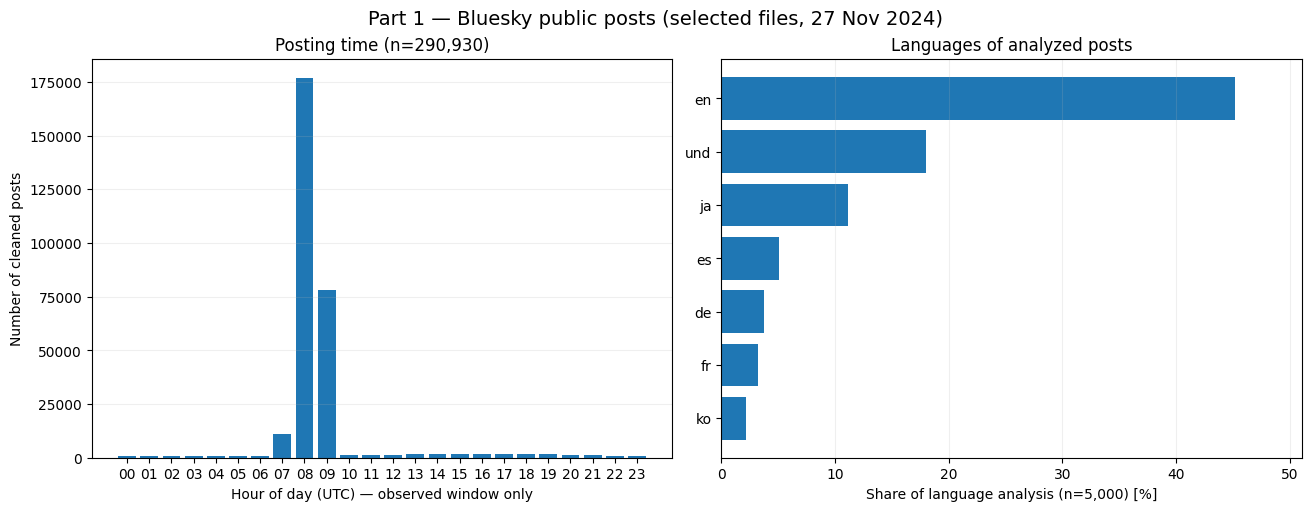

Saved: part1_results/part1_visualization.png


In [ ]:
# 11. Figure เดียว ครอบคลุมคำถามเวลาและภาษา
fig, axes = plt.subplots(ncols=2, figsize=(13,5), constrained_layout=True)
axes[0].bar(hourly['hour_utc'].astype(str).str.zfill(2), hourly['n_posts'])
axes[0].set_xlabel('Hour of day (UTC) — observed window only')
axes[0].set_ylabel('Number of cleaned posts')
axes[0].set_title(f'Posting time (n={len(df):,})')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=.2)

lang_plot = language_table.head(7).iloc[::-1]
axes[1].barh(lang_plot['language'],lang_plot['percent'])
axes[1].set_xlabel(f'Share of language analysis (n={len(lang_obs):,}) [%]')
axes[1].set_title('Languages of analyzed posts')
axes[1].set_xlim(0, max(10, float(lang_plot['percent'].max())*1.13))
axes[1].grid(axis='x',alpha=.2)
fig.suptitle('Part 1 — Bluesky public posts (selected files, 27 Nov 2024)',fontsize=14)
chart_path = RESULTS_DIR/'part1_visualization.png'
fig.savefig(chart_path,dpi=180,bbox_inches='tight')
plt.show()
print('Saved:',chart_path)

## 5. ตอบ 4 คำถาม และสรุปถึงลูกค้า 5 บรรทัด (สร้างจากผลที่รันได้จริง)
ข้อจำกัดที่ต้องระบุอย่างน้อย 3–5 บรรทัด: ข้อมูลสาธารณะและช่วงเวลาที่ถูกเลือกไม่ใช่ sample แบบสุ่มของผู้ใช้ทุกคน; ชั่วโมง UTC ไม่ใช่เวลาท้องถิ่น; การคาดเดาภาษาผิดได้ โดยเฉพาะโพสต์สั้น/หลายภาษา; hashtag และ bigram ไม่ยืนยันเจตนาของโพสต์ และข้อมูลนี้ไม่ใช่ตัวแทนของพฤติกรรมการซื้อเพลง/รีวิว Amazon.

In [ ]:
# 12. สร้างคำตอบรายงานโดยอ้างอิงตัวเลข computed เท่านั้น; ส่งออก Markdown และ CSV
peak_h = ', '.join(f'{h:02d}:00–{h:02d}:59' for h in peak_hours)
lang_summary = ', '.join(f"{r.language} {r.percent:.2f}% (n={int(r.n_posts):,})"
                         for r in language_table.head(3).itertuples(index=False))
tag_summary = (', '.join(f"#{r.hashtag} {int(r.n_posts):,} โพสต์ ({r.percent_of_all_posts:.2f}%)"
                         for r in hashtag_table.head(3).itertuples(index=False))
               if not hashtag_table.empty else 'ไม่พบ hashtag')
bigram_summary = (', '.join(bigrams_table['bigram'].head(3))
                  if not bigrams_table.empty else 'มีข้อความภาษาอังกฤษไม่เพียงพอสำหรับ bigram')
ex_lines = '\n'.join(f'- [{stamp}] {txt} ({uri})' for stamp,txt,uri in example_texts)
if not ex_lines:
    ex_lines = '- ไม่พบตัวอย่างโพสต์ที่มี hashtag ในไฟล์ที่เลือก'

report = f"""# Part 1 — Social Listening Warm-up

**Source:** {REPO_ID} (revision `{REVISION}`)
**JSONL files:** {', '.join(FILENAMES)}
**RANDOM_SEED:** {RANDOM_SEED}
**Data cleaning:** อ่าน {raw_records:,} records; invalid JSON {invalid_json:,}; แถว text/time ไม่ครบ {int(invalid_rows.sum()):,}; ซ้ำ {dup_count:,}; คงเหลือ {len(df):,} posts.

## คำถามที่ 1: คนโพสต์เมื่อไร?
หลัง clean มี **{len(df):,} โพสต์** ครอบคลุม **{start_utc.isoformat()} ถึง {end_utc.isoformat()} (UTC)**. ชั่วโมงที่พบมากที่สุดในไฟล์ที่เลือกคือ **{peak_h} UTC** จำนวน **{int(max_posts):,} โพสต์** (จาก `part1_hourly_counts.csv`).

## คำถามที่ 2: ใช้ภาษาอะไร?
วิธี: **{lang_method}**; จำนวนที่ใช้คำนวณภาษา **n={len(lang_obs):,}** (coverage predicted labels ในไฟล์ {label_coverage:.1%}). ภาษาหลักคือ **{main_language} {main_language_percent:.2f}%**. สามอันดับแรก: {lang_summary}. หากทำคอนเทนต์สำหรับผู้ใช้ที่มีลักษณะคล้ายตัวอย่างนี้ ควรเริ่มจากภาษาที่พบมาก แล้วทดสอบกับกลุ่มเป้าหมายจริงก่อนขยายภาษาอื่น (ตาราง `part1_language_share.csv`).

## คำถามที่ 3: คนพูดถึงอะไร?
Hashtags ที่ปรากฏในจำนวนโพสต์มากสุด: {tag_summary}. สำรวจเพิ่มเติมด้วย bigram บน random sample n={len(texts_for_topic):,} ได้วลี: {bigram_summary}. การตีความหัวข้อควรอ่านตัวอย่างโพสต์จริง ไม่สรุปจากความถี่เพียงอย่างเดียว.

### ข้อความจริงประกอบ (จาก sample ต้นฉบับ)
{ex_lines}

## คำถามที่ 4: ข้อมูลบอกอะไรได้/ไม่ได้?
**กราฟหลัก:** `part1_visualization.png` แสดงจำนวนโพสต์แยกตามชั่วโมง UTC และภาษาที่ตรวจได้ ภาพนี้อธิบายสิ่งที่เกิดขึ้นในไฟล์ที่เลือก ไม่ใช่พฤติกรรมของผู้ใช้ Bluesky ทั้งหมด.

**ข้อจำกัด (5 บรรทัด):**
1. วิเคราะห์เพียง {len(paths)} ไฟล์ JSONL ที่อยู่ติดกันในวันที่ 27 พ.ย. 2024 ไม่ใช่การสุ่มครอบคลุมทุกวันหรือ 24 ชั่วโมง จึงอ้างชั่วโมงพีกทั่วไปไม่ได้.
2. เป็นโพสต์สาธารณะที่ถูกเก็บผ่าน firehose; ผู้ใช้ที่ไม่โพสต์/โพสต์ส่วนตัวหรือผู้ใช้แพลตฟอร์มอื่นไม่อยู่ในกรอบนี้.
3. `created_at` ถูกแปลงเป็น UTC; ไม่ทราบ timezone ที่แท้จริงของผู้เขียน จึงตีความเวลาที่คนในประเทศใดตื่นหรือออนไลน์ไม่ได้.
4. ภาษาเป็นผลจากโมเดล/การสุ่ม sample (method: {lang_method}); โพสต์สั้นหรือปะปนหลายภาษาอาจจัดผิด และถ้าเป็น sample ค่าร้อยละเป็นค่าประมาณ.
5. Hashtags/bigrams เป็นเพียงหัวข้อในข้อความ ไม่ยืนยันความรู้สึก การซื้อเพลง หรือผลต่อยอดขาย; ควรทำ qualitative check และเก็บข้อมูลหลายวันก่อนตัดสินใจลงทุน.

## สรุปถึงลูกค้า 5 บรรทัด
1. ชุดตัวอย่างนี้มี {len(df):,} โพสต์จาก {len(paths)} ไฟล์ ระหว่าง {start_utc.strftime('%d %b %Y %H:%M')} ถึง {end_utc.strftime('%d %b %Y %H:%M')} UTC.
2. ชั่วโมงที่มีข้อความในตัวอย่างสูงสุดคือ {peak_h} UTC ({int(max_posts):,} โพสต์) แต่ไม่ควรเรียกว่าเวลาพีกตลอดวัน.
3. ภาษาที่ตรวจพบมากสุดคือ {main_language} ({main_language_percent:.2f}% ของ n={len(lang_obs):,} ที่ใช้ตรวจภาษา) จึงเป็นภาษาตั้งต้นสำหรับทดลองคอนเทนต์กับกลุ่มคล้ายตัวอย่าง.
4. ประเด็นสังคมที่เห็นจาก hashtag เป็น {('#'+top_tag) if top_tag else 'ไม่มี hashtag'}; ให้ตรวจข้อความจริงก่อนแปลงเป็นแคมเปญ และดูวลีที่พบร่วมกันในตาราง Bigram.
5. ฝ่าย Content สามารถทดลองเผยแพร่ตามภาษาหลัก/หัวข้อที่พบแล้ววัดอัตราการตอบสนองในกลุ่มเป้าหมายจริง; ข้อมูลนี้เพียงอย่างเดียวไม่ยืนยันว่ากลยุทธ์นั้นจะเพิ่มยอดขาย.
"""

report_path = RESULTS_DIR/'Part1_answers.md'
report_path.write_text(report, encoding='utf-8')
hourly.to_csv(RESULTS_DIR/'part1_hourly_counts.csv',index=False,encoding='utf-8-sig')
language_table.to_csv(RESULTS_DIR/'part1_language_share.csv',index=False,encoding='utf-8-sig')
hashtag_table.to_csv(RESULTS_DIR/'part1_hashtag_counts.csv',index=False,encoding='utf-8-sig')
quality.to_csv(RESULTS_DIR/'part1_quality_check.csv',index=False,encoding='utf-8-sig')
print('Generated:', report_path, '\nOther outputs:', sorted(p.name for p in RESULTS_DIR.iterdir()))
display(Markdown(report))

Generated: part1_results/Part1_answers.md 
Other outputs: ['Part1_answers.md', 'part1_hashtag_counts.csv', 'part1_hourly_counts.csv', 'part1_language_share.csv', 'part1_quality_check.csv', 'part1_visualization.png']


# Part 1 — Social Listening Warm-up

**Source:** alpindale/two-million-bluesky-posts (revision `4fda3b7f94f5f26871eec747d8217bab753c4d84`)  
**JSONL files:** posts_20241127_075630.jsonl, posts_20241127_082640.jsonl, posts_20241127_085625.jsonl  
**RANDOM_SEED:** 42  
**Data cleaning:** อ่าน 300,000 records; invalid JSON 0; แถว text/time ไม่ครบ 9,068; ซ้ำ 2; คงเหลือ 290,930 posts.

## คำถามที่ 1: คนโพสต์เมื่อไร?
หลัง clean มี **290,930 โพสต์** ครอบคลุม **2007-10-19T21:50:33+00:00 ถึง 2024-11-30T10:50:04.343000+00:00 (UTC)**. ชั่วโมงที่พบมากที่สุดในไฟล์ที่เลือกคือ **08:00–08:59 UTC** จำนวน **176,851 โพสต์** (จาก `part1_hourly_counts.csv`).

## คำถามที่ 2: ใช้ภาษาอะไร?
วิธี: **langdetect on fixed random sample (n=5,000, seed=42)**; จำนวนที่ใช้คำนวณภาษา **n=5,000** (coverage predicted labels ในไฟล์ 0.0%). ภาษาหลักคือ **en 45.18%**. สามอันดับแรก: en 45.18% (n=2,259), und 18.04% (n=902), ja 11.16% (n=558). หากทำคอนเทนต์สำหรับผู้ใช้ที่มีลักษณะคล้ายตัวอย่างนี้ ควรเริ่มจากภาษาที่พบมาก แล้วทดสอบกับกลุ่มเป้าหมายจริงก่อนขยายภาษาอื่น (ตาราง `part1_language_share.csv`).

## คำถามที่ 3: คนพูดถึงอะไร?
Hashtags ที่ปรากฏในจำนวนโพสต์มากสุด: #art 761 โพสต์ (0.26%), #innovation 538 โพสต์ (0.18%), #nsfw 497 โพสต์ (0.17%). สำรวจเพิ่มเติมด้วย bigram บน random sample n=20,000 ได้วลี: good morning, bsky app, en el. การตีความหัวข้อควรอ่านตัวอย่างโพสต์จริง ไม่สรุปจากความถี่เพียงอย่างเดียว.

### ข้อความจริงประกอบ (จาก sample ต้นฉบับ)
- [2024-11-27T08:42:13.903000+00:00] #Art #furry #fursona #oc (at://did:plc:vnu5s2vx6rtw3yyhqpa7qjeb/app.bsky.feed.post/3lbw5snzhmk2k)
- [2024-11-27T08:34:22.746000+00:00] Day 85 of #VampyDrawing 🎨

Finished shading to what I'm comfortable with. However I feel like this art style isnt what I want. Its cartoony, but not enough to be stylistic like PSG.

I want to have a more soft style, so i'll see if I can experiment to get that (at://did:plc:m37dvritztqiv4r363tqtvvf/app.bsky.feed.post/3lbw5emosgk2q)
- [2024-11-27T08:06:38.068000+00:00] Posting thisherw cuz I'm tired and wanna, soon here's smore art. #art #artist (at://did:plc:36eikucfhrn5pdciod3bezfl/app.bsky.feed.post/3lbw3sz54522r)

## คำถามที่ 4: ข้อมูลบอกอะไรได้/ไม่ได้?
**กราฟหลัก:** `part1_visualization.png` แสดงจำนวนโพสต์แยกตามชั่วโมง UTC และภาษาที่ตรวจได้ ภาพนี้อธิบายสิ่งที่เกิดขึ้นในไฟล์ที่เลือก ไม่ใช่พฤติกรรมของผู้ใช้ Bluesky ทั้งหมด.

**ข้อจำกัด (5 บรรทัด):**
1. วิเคราะห์เพียง 3 ไฟล์ JSONL ที่อยู่ติดกันในวันที่ 27 พ.ย. 2024 ไม่ใช่การสุ่มครอบคลุมทุกวันหรือ 24 ชั่วโมง จึงอ้างชั่วโมงพีกทั่วไปไม่ได้.
2. เป็นโพสต์สาธารณะที่ถูกเก็บผ่าน firehose; ผู้ใช้ที่ไม่โพสต์/โพสต์ส่วนตัวหรือผู้ใช้แพลตฟอร์มอื่นไม่อยู่ในกรอบนี้.
3. `created_at` ถูกแปลงเป็น UTC; ไม่ทราบ timezone ที่แท้จริงของผู้เขียน จึงตีความเวลาที่คนในประเทศใดตื่นหรือออนไลน์ไม่ได้.
4. ภาษาเป็นผลจากโมเดล/การสุ่ม sample (method: langdetect on fixed random sample (n=5,000, seed=42)); โพสต์สั้นหรือปะปนหลายภาษาอาจจัดผิด และถ้าเป็น sample ค่าร้อยละเป็นค่าประมาณ.
5. Hashtags/bigrams เป็นเพียงหัวข้อในข้อความ ไม่ยืนยันความรู้สึก การซื้อเพลง หรือผลต่อยอดขาย; ควรทำ qualitative check และเก็บข้อมูลหลายวันก่อนตัดสินใจลงทุน.

## สรุปถึงลูกค้า 5 บรรทัด
1. ชุดตัวอย่างนี้มี 290,930 โพสต์จาก 3 ไฟล์ ระหว่าง 19 Oct 2007 21:50 ถึง 30 Nov 2024 10:50 UTC.
2. ชั่วโมงที่มีข้อความในตัวอย่างสูงสุดคือ 08:00–08:59 UTC (176,851 โพสต์) แต่ไม่ควรเรียกว่าเวลาพีกตลอดวัน.
3. ภาษาที่ตรวจพบมากสุดคือ en (45.18% ของ n=5,000 ที่ใช้ตรวจภาษา) จึงเป็นภาษาตั้งต้นสำหรับทดลองคอนเทนต์กับกลุ่มคล้ายตัวอย่าง.
4. ประเด็นสังคมที่เห็นจาก hashtag เป็น #art; ให้ตรวจข้อความจริงก่อนแปลงเป็นแคมเปญ และดูวลีที่พบร่วมกันในตาราง Bigram.
5. ฝ่าย Content สามารถทดลองเผยแพร่ตามภาษาหลัก/หัวข้อที่พบแล้ววัดอัตราการตอบสนองในกลุ่มเป้าหมายจริง; ข้อมูลนี้เพียงอย่างเดียวไม่ยืนยันว่ากลยุทธ์นั้นจะเพิ่มยอดขาย.


### Checklist ก่อนส่งงานเดี่ยว
- [ ] นักศึกษาทดลองรันทุกเซลล์ด้วยอินเทอร์เน็ตใน Google Colab และตรวจว่ามี output/graph จริง
- [ ] ตรวจตัวเลข `n`, ช่วงวันที่และตัวอย่างข้อความที่คำนวณจากชุดไฟล์ที่ดาวน์โหลด; แก้คำบรรยายให้ตรงกับผลที่ได้
- [ ] ตรวจรายงานว่าไม่ตีความ peak hour เกินขอบเขตข้อมูล และไม่อ้างว่า language detection ถูก 100%
- [ ] ใส่ชื่อและรหัสของผู้ทำงาน และอธิบายเหตุผลเลือก 3 ไฟล์/วิธีวิเคราะห์ด้วยตนเอง
- [ ] ดาวน์โหลด Notebook แบบ **File → Download → Download .ipynb** โดยเก็บผลรันไว้; ส่ง Part 1 แยกจากงานกลุ่ม

**หมายเหตุ:** Notebook นี้ตั้งใจให้รันจริงแล้วสร้างผล ไม่ได้ใส่ผลลัพธ์ปลอมหรือใช้ข้อมูล NASA/Twitter ทดแทน Bluesky. ไม่ต้องทำ influencer analysis หรือ reply-network สำหรับ Part 1.